In [1]:
! pip uninstall xgboost -y
! pip install xgboost==2.1.4


18.79s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Found existing installation: xgboost 3.0.0
Uninstalling xgboost-3.0.0:
  Successfully uninstalled xgboost-3.0.0


27.95s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached xgboost-2.1.4-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-2.1.4-py3-none-manylinux_2_28_x86_64.whl (223.6 MB)


In [ ]:
import xgboost
print(xgboost.__file__)  # Path to the installed package

In [3]:
import sklearn
print(sklearn.__version__)  # Should be 1.4.x or higher

1.6.1


In [4]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization purposes
import seaborn as sns # for statistical data visualization
%matplotlib inline



In [5]:
import warnings
warnings.filterwarnings('ignore')

# **6. Import dataset** <a class="anchor" id="6"></a>

[Table of Contents](#0.1)

In [6]:

df = pd.read_csv("../data/adult.csv") #, sep=',\s')
df.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


### Number of labels: cardinality


The number of labels within a categorical variable is known as **cardinality**. A high number of labels within a variable is known as **high cardinality**. High cardinality may pose some serious problems in the machine learning model. So, I will check for high cardinality.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   39              32560 non-null  int64 
 1    State-gov      32560 non-null  object
 2    77516          32560 non-null  int64 
 3    Bachelors      32560 non-null  object
 4    13             32560 non-null  int64 
 5    Never-married  32560 non-null  object
 6    Adm-clerical   32560 non-null  object
 7    Not-in-family  32560 non-null  object
 8    White          32560 non-null  object
 9    Male           32560 non-null  object
 10   2174           32560 non-null  int64 
 11   0              32560 non-null  int64 
 12   40             32560 non-null  int64 
 13   United-States  32560 non-null  object
 14   <=50K          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
for col in df.select_dtypes("object").columns:
    print(f" {col:-<30} {df[col].nunique()}")

  State-gov-------------------- 9
  Bachelors-------------------- 16
  Never-married---------------- 7
  Adm-clerical----------------- 15
  Not-in-family---------------- 6
  White------------------------ 5
  Male------------------------- 2
  United-States---------------- 42
  <=50K------------------------ 2


### Explore Numerical Variables

In [9]:
# check missing values in numerical variables

df.isnull().sum()

39                0
 State-gov        0
 77516            0
 Bachelors        0
 13               0
 Never-married    0
 Adm-clerical     0
 Not-in-family    0
 White            0
 Male             0
 2174             0
 0                0
 40               0
 United-States    0
 <=50K            0
dtype: int64

We can see that all the 6 numerical variables do not contain missing values.

In [10]:
df.iloc[:, 1:]

,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32556,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32557,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32558,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [11]:
df.iloc[:, 1:-1].sample()

,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
17622,Private,183765,Some-college,10,Divorced,Tech-support,Not-in-family,White,Male,0,0,40,?


In [12]:
df.iloc[:, 1:].sample()

,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
26647,Private,253354,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K


In [ ]:
# label encoder of the taget Final_Grade having values [A, B , C D]
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df.iloc[:, -1] = le.fit_transform(df.iloc[:, -1])
df.Final_Grade= df.Final_Grade.astype(int)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Student_ID                               10000 non-null  object
 1   Age                                      10000 non-null  int64 
 2   Gender                                   10000 non-null  object
 3   Study_Hours_per_Week                     10000 non-null  int64 
 4   Preferred_Learning_Style                 10000 non-null  object
 5   Online_Courses_Completed                 10000 non-null  int64 
 6   Participation_in_Discussions             10000 non-null  object
 7   Assignment_Completion_Rate (%)           10000 non-null  int64 
 8   Exam_Score (%)                           10000 non-null  int64 
 9   Attendance_Rate (%)                      10000 non-null  int64 
 10  Use_of_Educational_Tech                  10000 non-null  ob

In [128]:
df = pd.get_dummies(
    df.iloc[:, 1:],  # Exclude Student_ID
    columns=df.iloc[:, 1:].select_dtypes("object").columns,  # Object columns from sliced data
    drop_first=True,  # Avoid multicollinearity
    dtype=int  # Use integers (0/1)
)

# **8. Declare feature vector and target variable** <a class="anchor" id="8"></a>

[Table of Contents](#0.1)

In [13]:
X = df.drop("Final_Grade", axis=1)

y =df["Final_Grade"]

KeyError: "['Final_Grade'] not found in axis"

# **9. Split data into separate training and test set** <a class="anchor" id="9"></a>

[Table of Contents](#0.1)

In [ ]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

# First, split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Then, split the temp set into validation (50% of temp = 15% of total) and test (50% of temp = 15% of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [ ]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape, X_val.shape

((7000, 17), (1500, 17), (1500, 17))

In [ ]:
X_train.head()

,Age,Study_Hours_per_Week,Online_Courses_Completed,Assignment_Completion_Rate (%),Exam_Score (%),Attendance_Rate (%),Time_Spent_on_Social_Media (hours/week),Sleep_Hours_per_Night,Gender_Male,Gender_Other,Preferred_Learning_Style_Kinesthetic,Preferred_Learning_Style_Reading/Writing,Preferred_Learning_Style_Visual,Participation_in_Discussions_Yes,Use_of_Educational_Tech_Yes,Self_Reported_Stress_Level_Low,Self_Reported_Stress_Level_Medium
9069,25,48,1,98,55,85,20,8,0,0,0,0,1,1,1,0,1
2603,23,28,17,90,62,84,12,10,0,0,0,1,0,1,1,0,1
7738,26,14,20,75,90,71,18,4,1,0,0,0,1,1,1,0,1
1579,19,7,0,56,72,95,8,6,0,0,0,0,1,1,1,0,1
5058,18,20,16,90,64,58,3,6,1,0,1,0,0,0,0,1,0


In [ ]:
from xgboost import XGBClassifier
import xgboost
print("XGBoost version:", xgboost.__version__)  # Should print 2.1.4
print("XGBClassifier source:", XGBClassifier.__module__)  # Should print 'xgboost.sklearn'

XGBoost version: 2.1.4
XGBClassifier source: xgboost.sklearn


In [ ]:
# Classifier
classifier = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss'
)



In [ ]:
# Fit
classifier.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    # early_stopping_rounds=10,
    verbose=True
)

[0]	validation_0-mlogloss:0.85417	validation_1-mlogloss:0.85417
[1]	validation_0-mlogloss:0.58136	validation_1-mlogloss:0.58136
[2]	validation_0-mlogloss:0.40944	validation_1-mlogloss:0.40944
[3]	validation_0-mlogloss:0.29350	validation_1-mlogloss:0.29350
[4]	validation_0-mlogloss:0.21263	validation_1-mlogloss:0.21263
[5]	validation_0-mlogloss:0.15511	validation_1-mlogloss:0.15511
[6]	validation_0-mlogloss:0.11369	validation_1-mlogloss:0.11369
[7]	validation_0-mlogloss:0.08362	validation_1-mlogloss:0.08362
[8]	validation_0-mlogloss:0.06166	validation_1-mlogloss:0.06166
[9]	validation_0-mlogloss:0.04556	validation_1-mlogloss:0.04556
[10]	validation_0-mlogloss:0.03373	validation_1-mlogloss:0.03373
[11]	validation_0-mlogloss:0.02501	validation_1-mlogloss:0.02501
[12]	validation_0-mlogloss:0.01857	validation_1-mlogloss:0.01857
[13]	validation_0-mlogloss:0.01382	validation_1-mlogloss:0.01382
[14]	validation_0-mlogloss:0.01031	validation_1-mlogloss:0.01031
[15]	validation_0-mlogloss:0.00771	

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=4, num_parallel_tree=None, ...)

In [ ]:
# Step 6: Predict (optional)
y_pred = classifier.predict(X_test)
print("Predictions:", y_pred)

Predictions: [1 1 1 ... 2 0 3]


In [ ]:
eval_result= classifier.evals_result()
training_rounds = range(len(eval_result['validation_0']['mlogloss']))
training_rounds


range(0, 100)

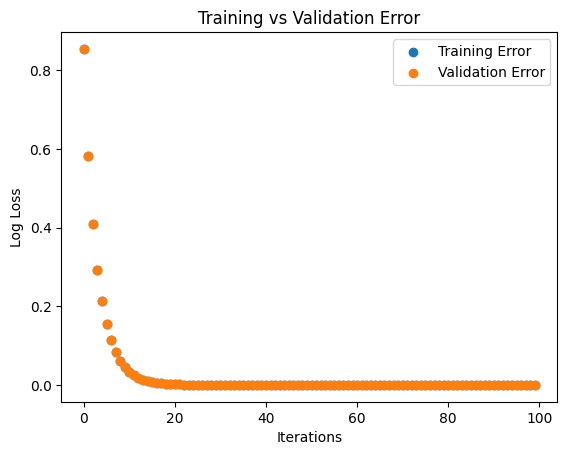

In [ ]:
plt.scatter(x=training_rounds, y=eval_result['validation_0']['mlogloss'], label='Training Error')
plt.scatter(x=training_rounds, y=eval_result['validation_1']['mlogloss'], label='Validation Error')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Error')
plt.legend()
plt.show()

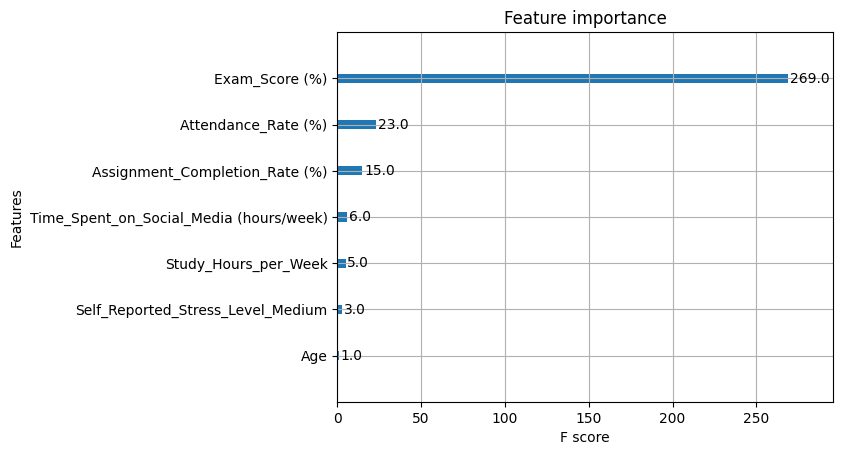

In [ ]:
import matplotlib.pyplot as plt
import xgboost as   xgb
xgb.plot_importance(classifier)
plt.show()

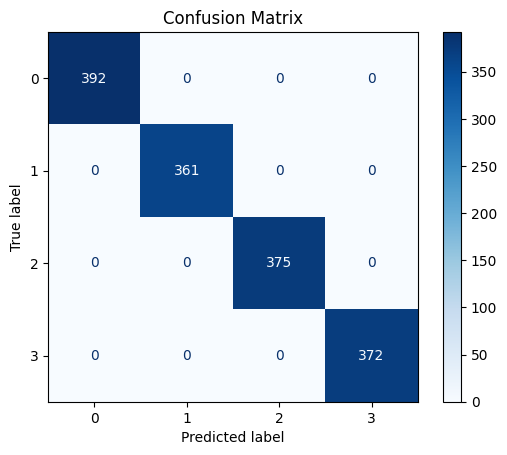

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay.from_estimator(
    classifier,
    X_test,
    y_test,
    cmap=plt.cm.Blues,  # Color map for the plot
    # normalize='true' # Uncomment to display normalized values (percentages)
)
disp.ax_.set_title('Confusion Matrix')
plt.show()

## Early Stop

In [ ]:
# Convert data to DMatrix (XGBoost's internal format)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# Define parameters
params = {
    'objective': 'multi:softprob',  # Adjust based on your task
    'eval_metric': 'mlogloss',
      'num_class': 4
}
evals = [(dtrain, 'train'), (dval, 'val')]
print("Starting XGBoost training with early stopping...")
num_boost_round = 100 # Set a sufficiently high number of max rounds
# Train the model
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round, # Maximum number of boosting rounds
    evals=evals,
    early_stopping_rounds=10, # Stops if 'mlogloss' on 'val' set doesn't improve for 10 rounds
    verbose_eval=10 # Print evaluation results every 10 rounds
    # verbose_eval=True # Print results every round
    # verbose_eval=False # Print only the final results if stopped early
)

Starting XGBoost training with early stopping...
[0]	train-mlogloss:0.85417	val-mlogloss:0.85417
[10]	train-mlogloss:0.03373	val-mlogloss:0.03373
[20]	train-mlogloss:0.00193	val-mlogloss:0.00193
[30]	train-mlogloss:0.00031	val-mlogloss:0.00031
[40]	train-mlogloss:0.00029	val-mlogloss:0.00028
[50]	train-mlogloss:0.00028	val-mlogloss:0.00028
[60]	train-mlogloss:0.00028	val-mlogloss:0.00028
[70]	train-mlogloss:0.00028	val-mlogloss:0.00028
[79]	train-mlogloss:0.00028	val-mlogloss:0.00028


In [ ]:
print(f"\nTraining finished.")
if bst.best_iteration != num_boost_round-1 : # Check if early stopping occurred (best_iteration is 0-indexed)
     print(f"Early stopping occurred at round {bst.best_iteration + 1} (best score: {bst.best_score:.4f})")
else:
     print(f"Training completed {bst.num_boosted_rounds()} rounds without early stopping.")



Training finished.
Early stopping occurred at round 71 (best score: 0.0003)


In [ ]:
#  prediction (outputs probabilities for multi:softprob)
dtest = xgb.DMatrix(X_test) # Assuming you have X_test
y_pred_proba = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))
y_pred_labels = np.argmax(y_pred_proba, axis=1) # To get class labels

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss  # Since your eval_metric was mlogloss
)


In [ ]:
# a) Accuracy Score
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"\nAccuracy on Test Set: {accuracy:.4f}")


Accuracy on Test Set: 1.0000


In [ ]:
# Assuming labels are 0 to num_class-1 as required by XGBoost multi:softprob
logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss on Test Set: {logloss:.4f}")

Log Loss on Test Set: 0.0003


In [ ]:

print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       392
           1       1.00      1.00      1.00       361
           2       1.00      1.00      1.00       375
           3       1.00      1.00      1.00       372

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



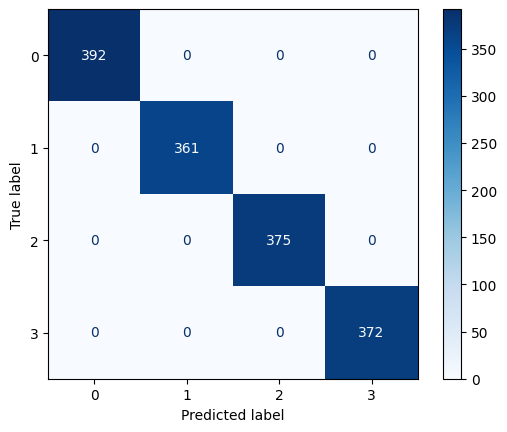

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_labels,
        # display_labels=y.unique(), # Use class names if available
        cmap=plt.cm.Blues,
        # normalize='true' # Optional: display percentages
    )

In [ ]:
# plot learning curve


In [ ]:
best_hyperparams = {
    'objective': params.get('objective', 'multi:softprob'),
    'eval_metric': params.get('eval_metric', 'mlogloss'),
    # Translate parameters back if needed:
    'learning_rate': params.get('eta', 0.1), # Example: eta -> learning_rate
    'max_depth': params.get('max_depth', 6),
    'subsample': params.get('subsample', 1.0),
    'colsample_bytree': params.get('colsample_bytree', 1.0),
    'gamma': params.get('gamma', 0),
    'reg_lambda': params.get('lambda', 1), # Example: lambda -> reg_lambda
    'reg_alpha': params.get('alpha', 0),   # Example: alpha -> reg_alpha
    'seed': params.get('seed', 42),
    # Use the optimal number of trees found by early stopping in xgb.train
    # We fit with this specific number inside learning_curve
    'n_estimators': bst.best_iteration + 1,
    # No early stopping here - learning_curve handles the fitting process
}

In [ ]:
# Create an *untrained* instance of the classifier
# For multi-class, objective/eval_metric are often handled automatically,
# but specifying them can ensure consistency. num_class is not needed here.
final_classifier = XGBClassifier(**best_hyperparams)

print("Using XGBClassifier for learning curve with parameters:")
print(final_classifier.get_params()) # Verify parameters

Using XGBClassifier for learning curve with parameters:
{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'mlogloss', 'feature_types': None, 'gamma': 0, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 71, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': 0, 'reg_lambda': 1, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 1.0, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'seed': 42}


In [ ]:
# --- 2. Define Training Sizes and Call learning_curve ---
from sklearn.model_selection import learning_curve

# Define the relative sizes of the training sets to use
# e.g., 10%, 20%, ..., 100% of the training data
train_sizes_abs, train_scores, test_scores = learning_curve(
    estimator=final_classifier,
    X=X_train, # Your full training features
    y=y_train, # Your full training labels
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 steps from 10% to 100%
    cv=5, # Number of cross-validation folds (adjust as needed)
    scoring='accuracy', # Or your primary metric (e.g., 'f1_macro', 'neg_log_loss')
    n_jobs=-1, # Use all available CPU cores
    random_state=42 # Ensure reproducibility of CV splits
)


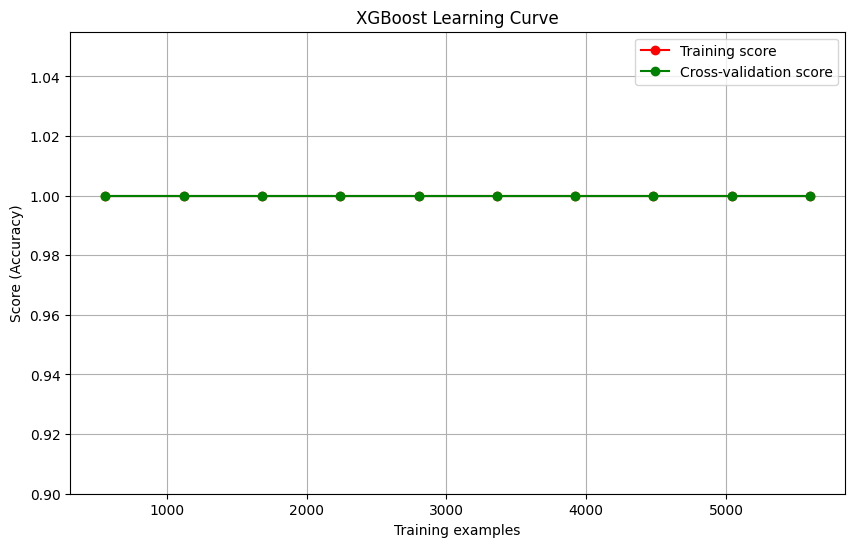

In [ ]:





# --- 3. Calculate Mean and Std Dev for Plotting ---
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# --- 4. Plot the Learning Curve ---
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g", label="Cross-validation score")

plt.title('XGBoost Learning Curve')
plt.xlabel('Training examples')
plt.ylabel('Score (Accuracy)')
plt.legend(loc="best")
plt.grid(True)
plt.ylim(bottom=max(0, test_scores_mean.min() - 0.1)) # Adjust y-axis lower limit
plt.show()
